# Сравнительный анализ методов слепой деконволюции

Ноутбук автоматически сканирует папку `presentation_graphics/` и строит сводные графики и таблицы для всех протестированных алгоритмов.

**Структура данных:**
```
presentation_graphics/
├── ALG_NAME_1/
│   ├── test1/results_ALG1_test1.csv
│   ├── test2/results_ALG1_test2.csv
│   └── all_results_ALG1.csv
├── ALG_NAME_2/
│   └── ...
```

Каждый CSV содержит столбцы: `dataset, distorted_file, image_name, kernel_name, noise_name, psnr, ssim, error_ratio, time_sec, ...`

In [1]:
# ══════════════════════════════════════════════════════════════════════════════
# ЯЧЕЙКА 1. Загрузка данных из всех папок алгоритмов
# ══════════════════════════════════════════════════════════════════════════════
import sys, os
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

import visualisation as vis  # <-- все графики и TeX-генерация

# ── Автоопределение корня проекта ────────────────────────────────────────────
_nb_dir = Path(os.path.abspath("")).resolve()
PROJECT_ROOT = _nb_dir
for _p in [_nb_dir] + list(_nb_dir.parents):
    if (_p / "pyproject.toml").exists() or (_p / "src").is_dir():
        PROJECT_ROOT = _p
        break

sys.path.insert(0, str(PROJECT_ROOT))
sys.path.insert(0, str(PROJECT_ROOT / "src"))
os.chdir(PROJECT_ROOT)


RESULTS_ROOT = PROJECT_ROOT / "presentation_graphics"
TEX_DIR = RESULTS_ROOT / "comparison_tex"
TEX_DIR.mkdir(exist_ok=True)
FIG_DIR = RESULTS_ROOT / "comparison_figures"
FIG_DIR.mkdir(exist_ok=True)

plt.rcParams.update({'font.size': 12, 'figure.dpi': 120,
                     'savefig.dpi': 150, 'savefig.bbox': 'tight'})

# ── Сканирование результатов ─────────────────────────────────────────────────
all_data = {}  # { algorithm_name: DataFrame }

for alg_dir in sorted(RESULTS_ROOT.iterdir()):
    if not alg_dir.is_dir():
        continue
    if alg_dir.name.startswith("comparison"):
        continue

    alg_name = alg_dir.name
    csvs = list(alg_dir.glob("*/results_*.csv")) + list(alg_dir.glob("all_results_*.csv"))

    frames = []
    for csv_file in csvs:
        try:
            df = pd.read_csv(csv_file)
            if 'algorithm' not in df.columns:
                df['algorithm'] = alg_name
            frames.append(df)
        except Exception as e:
            print(f"  Ошибка чтения {csv_file}: {e}")

    if frames:
        combined = pd.concat(frames, ignore_index=True)
        if 'distorted_file' in combined.columns and 'dataset' in combined.columns:
            combined = combined.drop_duplicates(subset=['distorted_file', 'dataset'], keep='last')
        all_data[alg_name] = combined
        print(f"✓ {alg_name}: {len(combined)} записей из {len(csvs)} CSV")
    else:
        print(f"✗ {alg_name}: CSV не найдены")

print(f"\nВсего алгоритмов: {len(all_data)}")
print(f"Алгоритмы: {list(all_data.keys())}")

# Общий DataFrame
if all_data:
    df_global = pd.concat(all_data.values(), ignore_index=True)
    datasets = df_global['dataset'].dropna().unique().tolist()
    print(f"Наборы данных: {datasets}")
else:
    df_global = pd.DataFrame()
    datasets = []
    print("Нет данных для анализа!")

✓ LIP-PD: 9 записей из 4 CSV
✓ VDBKE: 9 записей из 4 CSV

Всего алгоритмов: 2
Алгоритмы: ['LIP-PD', 'VDBKE']
Наборы данных: ['test1', 'test2', 'test3']


## 2. Доля успешных / отношение ошибки (сравнительный)

Кумулятивный график доли успешных примеров в зависимости от порога отношения ошибки.
Чем левее и выше кривая, тем лучше алгоритм.

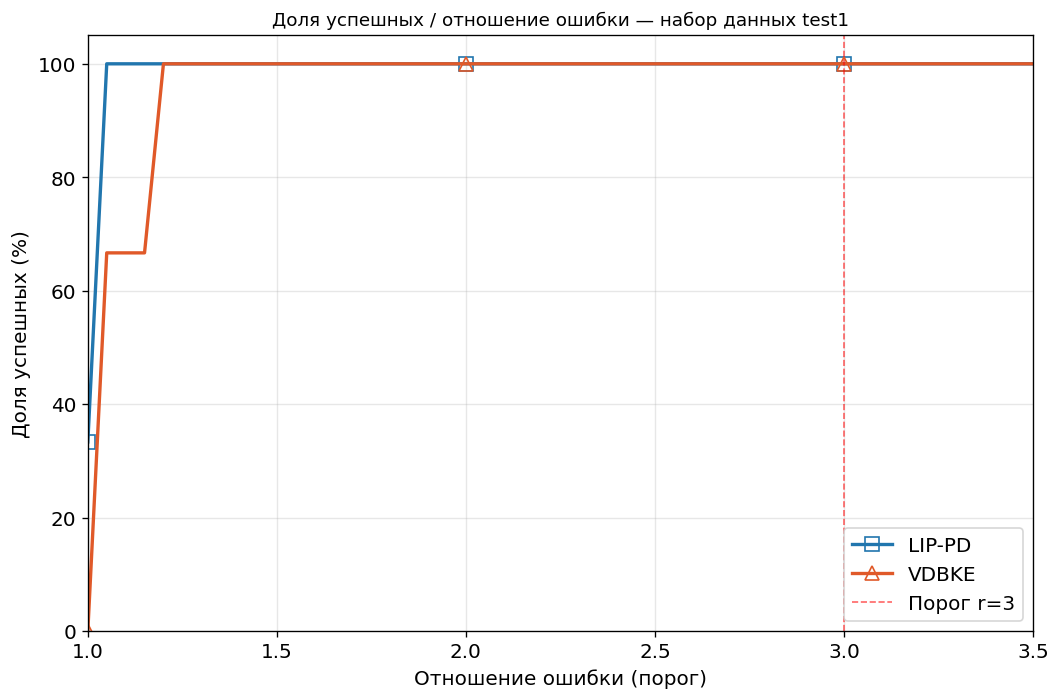

  TeX сохранён: D:\for_proga\franework_deconvolution\framework (9)\presentation_graphics\comparison_tex\success_rate_test1.tex


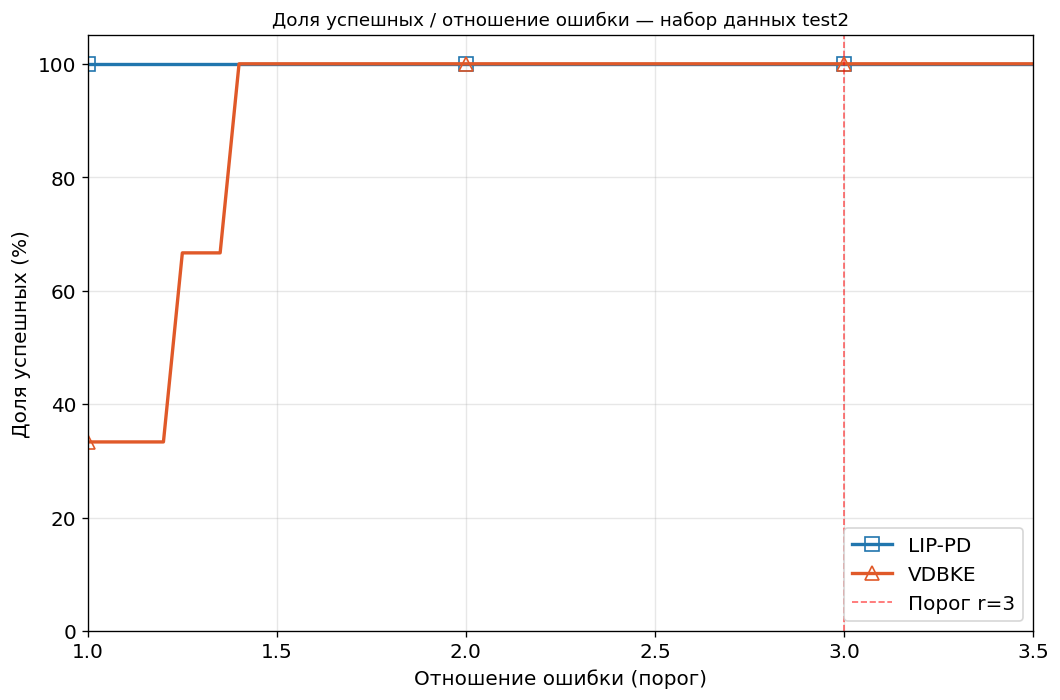

  TeX сохранён: D:\for_proga\franework_deconvolution\framework (9)\presentation_graphics\comparison_tex\success_rate_test2.tex
  Набор данных test3: нет данных отношения ошибки


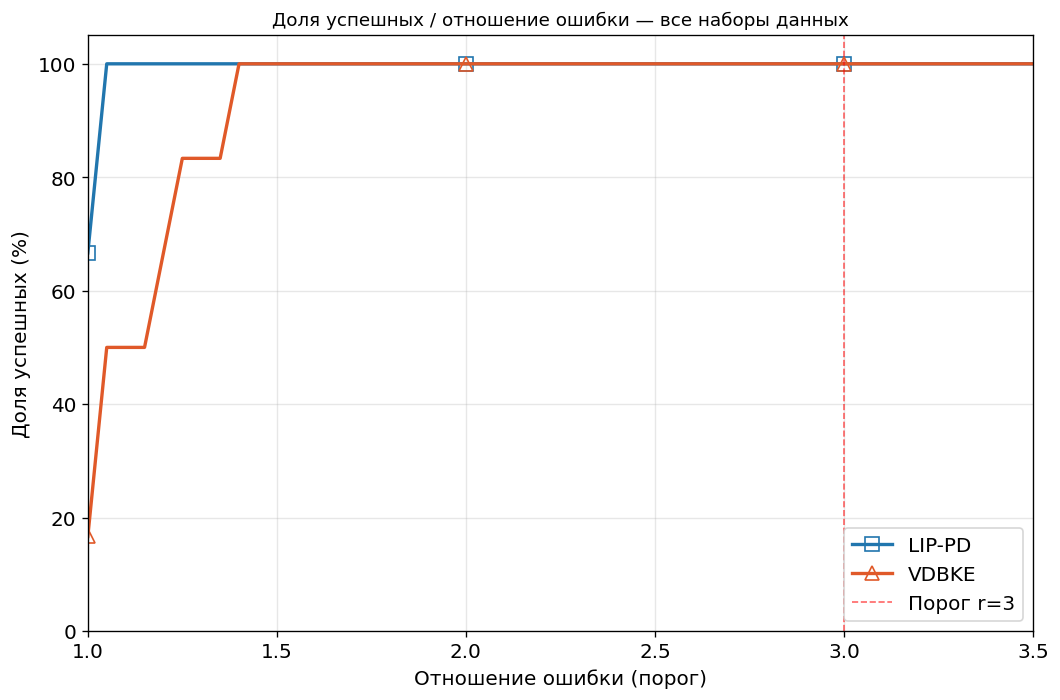

  TeX сохранён: D:\for_proga\franework_deconvolution\framework (9)\presentation_graphics\comparison_tex\success_rate_all.tex


In [2]:
# ══════════════════════════════════════════════════════════════════════════════
# 2. Доля успешных / отношение ошибки (сравнительный)
# ══════════════════════════════════════════════════════════════════════════════
vis.plot_success_rate_comparison(
    all_data, datasets, fig_dir=FIG_DIR, tex_dir=TEX_DIR,
    fig_prefix="comparison_figures",
)

## 3. Столбчатая диаграмма PSNR / SSIM по алгоритмам

Средние значения PSNR и SSIM для каждого алгоритма.

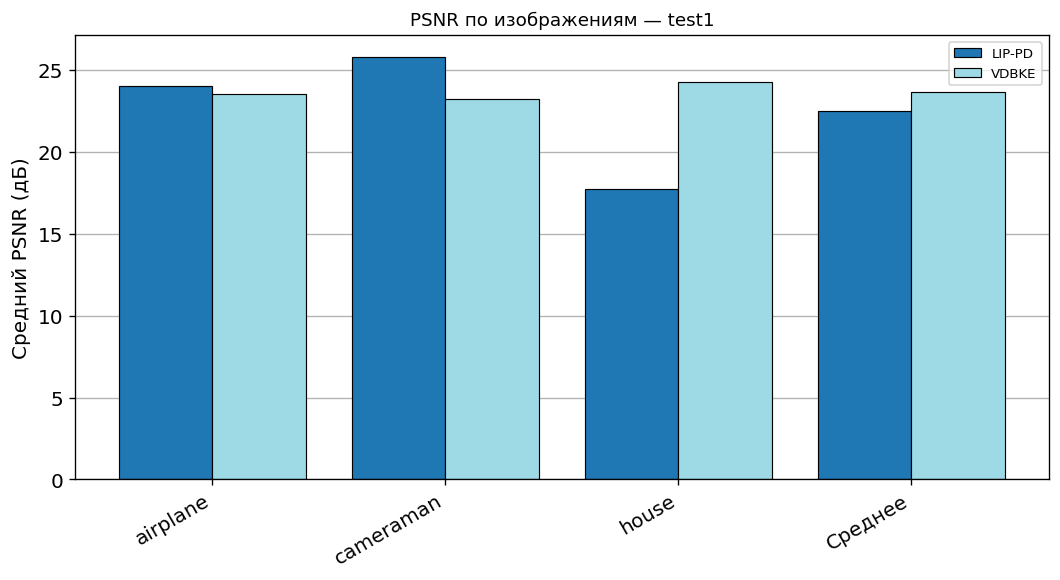

  TeX сохранён: D:\for_proga\franework_deconvolution\framework (9)\presentation_graphics\comparison_tex\bar_psnr_test1.tex


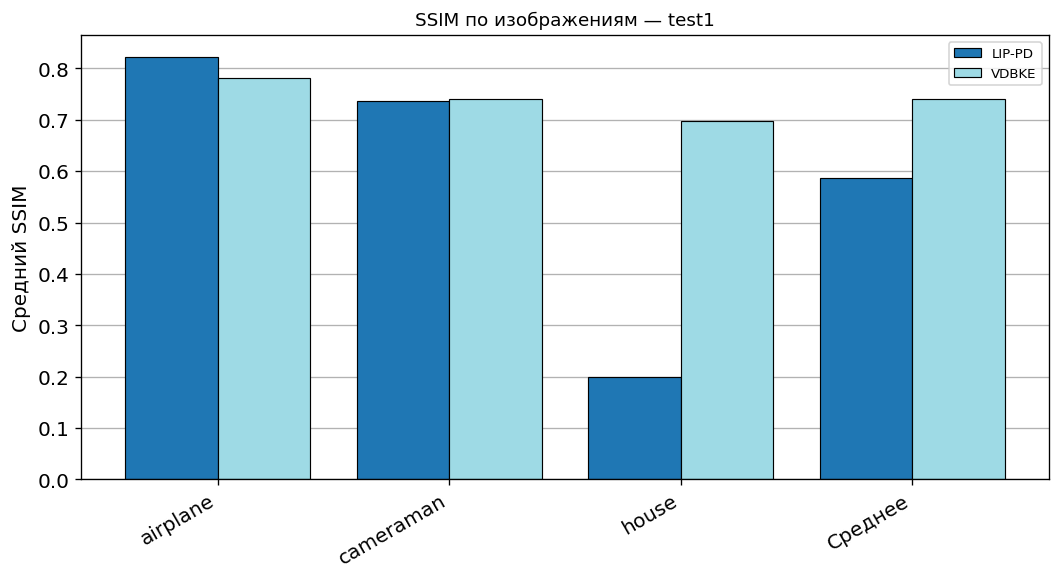

  TeX сохранён: D:\for_proga\franework_deconvolution\framework (9)\presentation_graphics\comparison_tex\bar_ssim_test1.tex


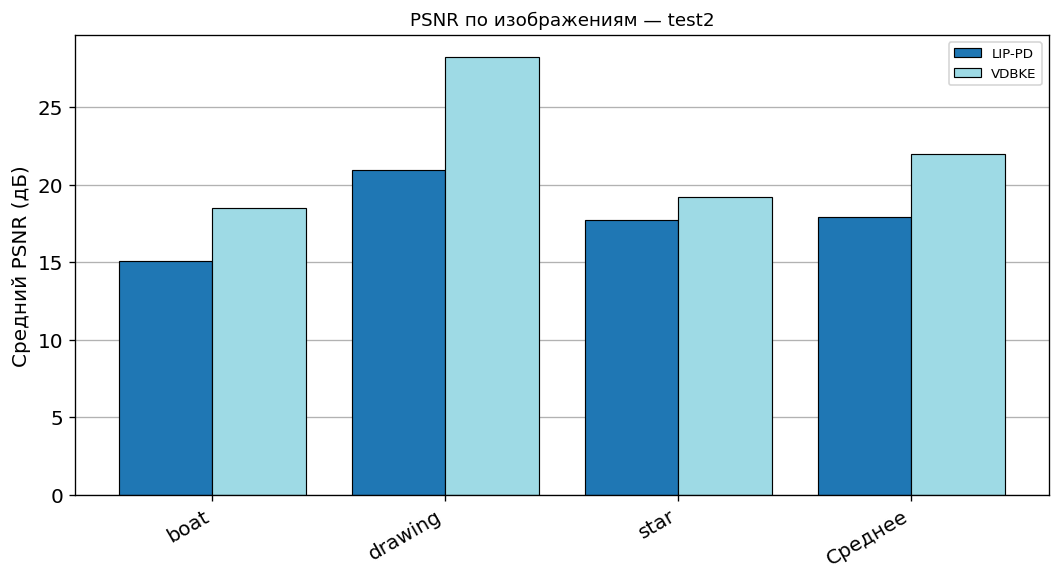

  TeX сохранён: D:\for_proga\franework_deconvolution\framework (9)\presentation_graphics\comparison_tex\bar_psnr_test2.tex


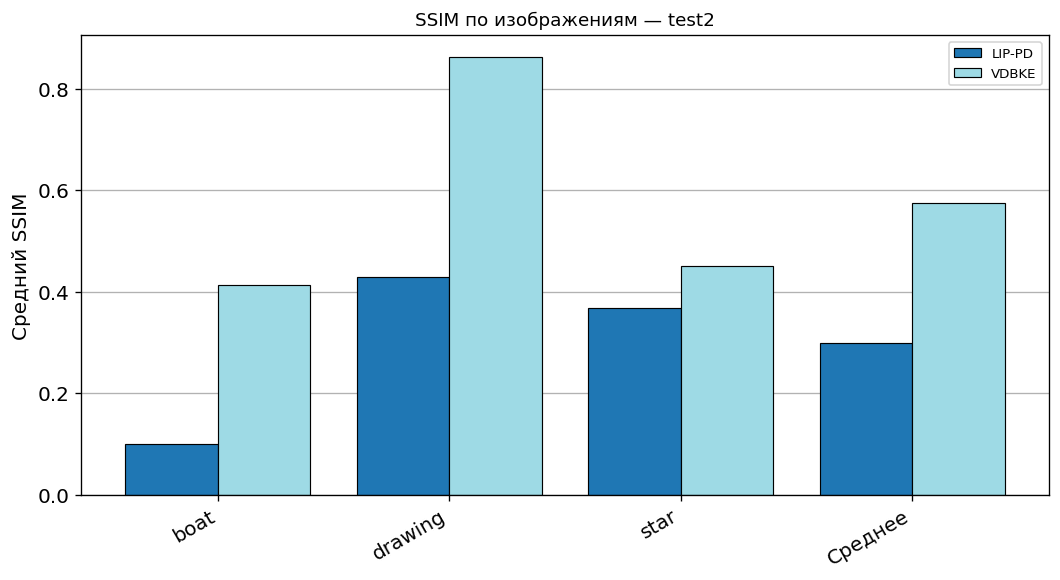

  TeX сохранён: D:\for_proga\franework_deconvolution\framework (9)\presentation_graphics\comparison_tex\bar_ssim_test2.tex


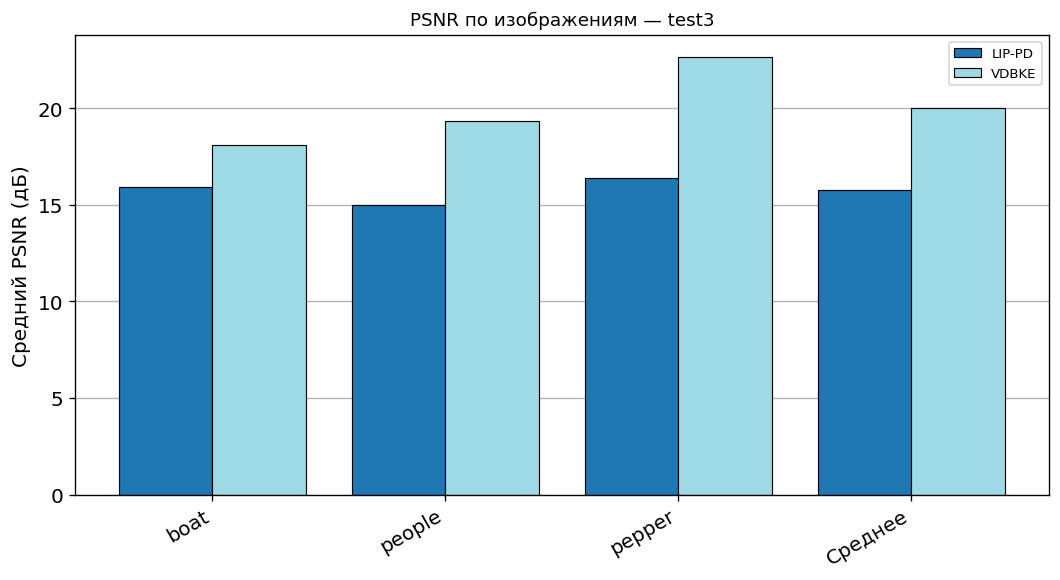

  TeX сохранён: D:\for_proga\franework_deconvolution\framework (9)\presentation_graphics\comparison_tex\bar_psnr_test3.tex


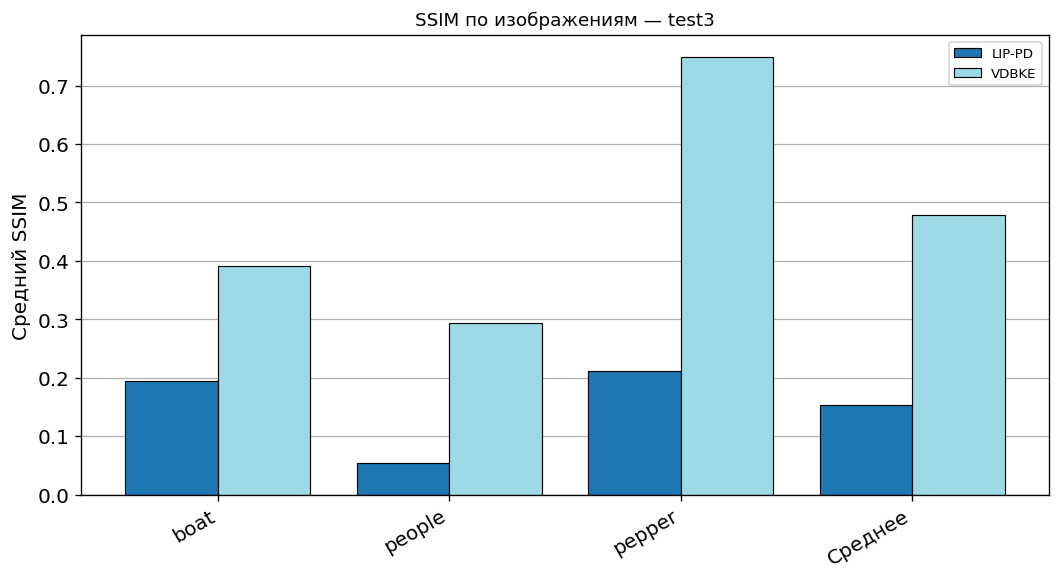

  TeX сохранён: D:\for_proga\franework_deconvolution\framework (9)\presentation_graphics\comparison_tex\bar_ssim_test3.tex


In [3]:
# ══════════════════════════════════════════════════════════════════════════════
# 3. Столбчатая диаграмма средних PSNR / SSIM по алгоритмам
# ══════════════════════════════════════════════════════════════════════════════
vis.plot_bar_psnr_ssim_comparison(
    all_data, datasets, fig_dir=FIG_DIR, tex_dir=TEX_DIR,
    fig_prefix="comparison_figures",
)

## 6. Гистограмма отношения ошибки + 8. Зависимость от размера ядра + 9. Боксплоты

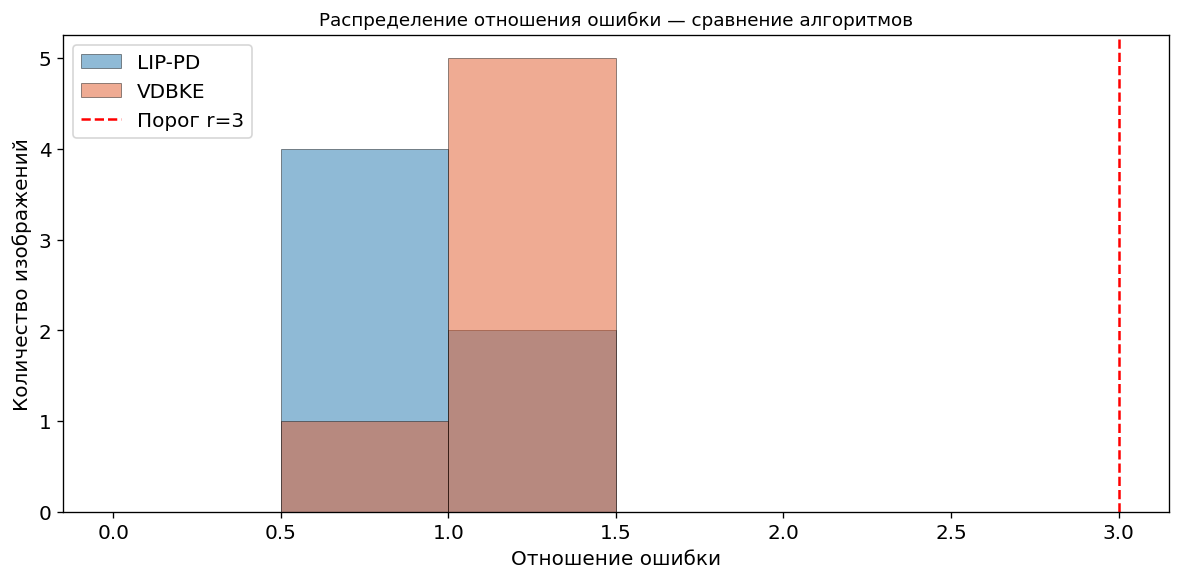

  TeX сохранён: D:\for_proga\franework_deconvolution\framework (9)\presentation_graphics\comparison_tex\error_ratio_hist_cmp.tex


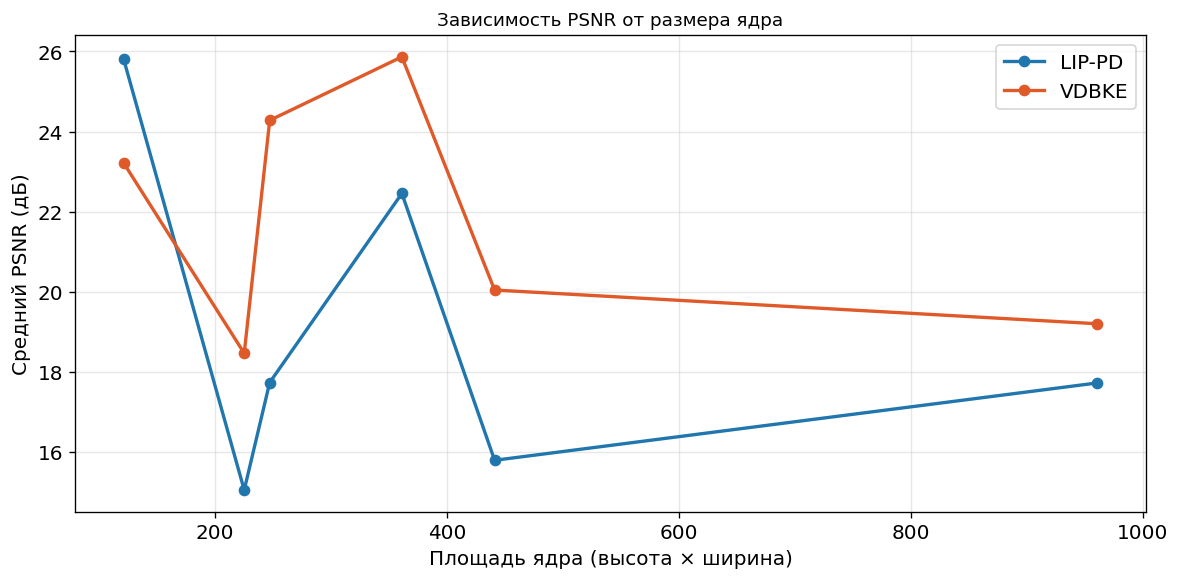

  TeX сохранён: D:\for_proga\franework_deconvolution\framework (9)\presentation_graphics\comparison_tex\kernel_size_psnr_cmp.tex


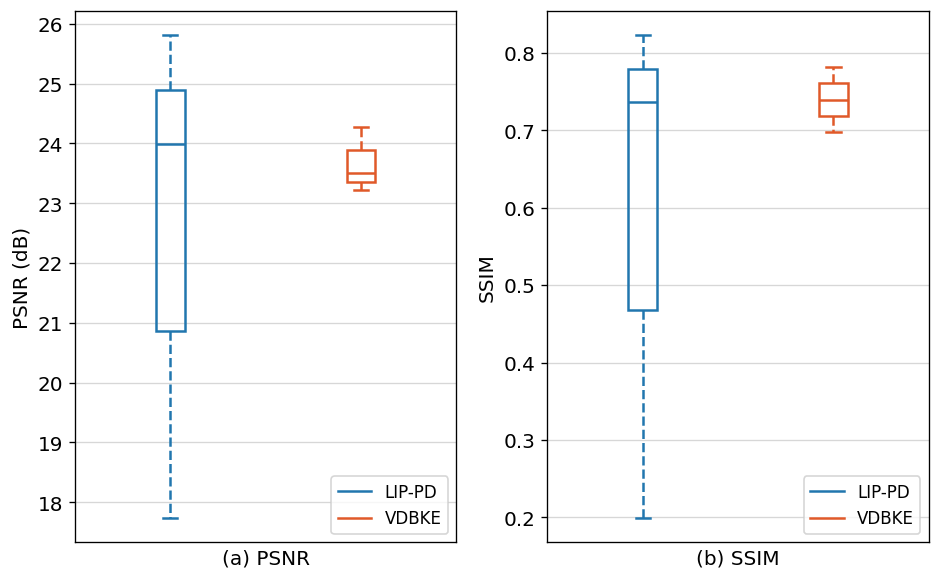

  TeX сохранён: D:\for_proga\franework_deconvolution\framework (9)\presentation_graphics\comparison_tex\boxplot_test1.tex


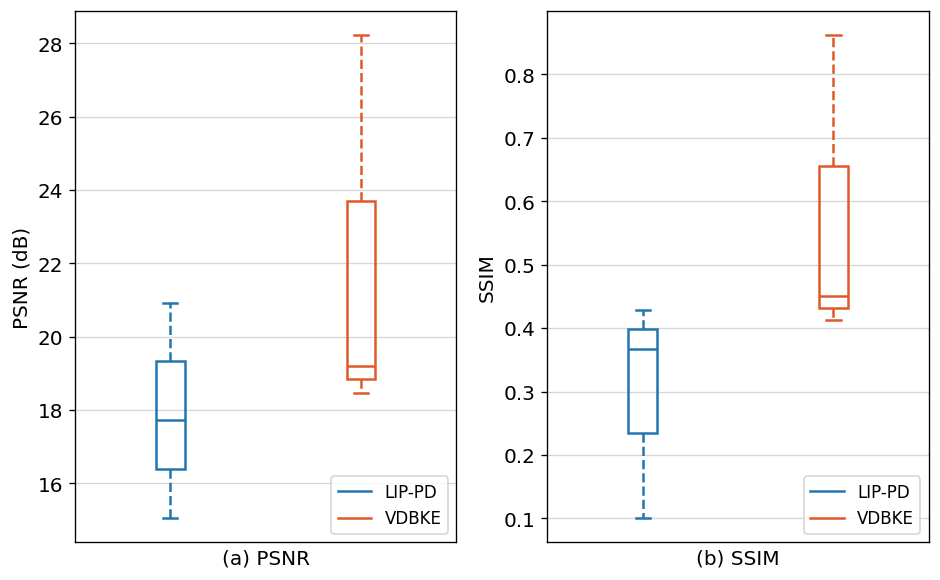

  TeX сохранён: D:\for_proga\franework_deconvolution\framework (9)\presentation_graphics\comparison_tex\boxplot_test2.tex


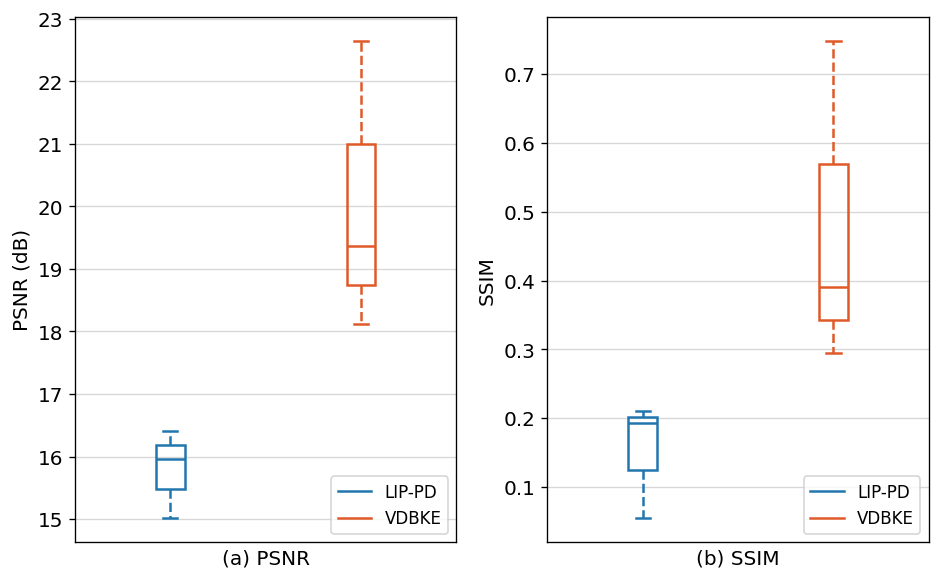

  TeX сохранён: D:\for_proga\franework_deconvolution\framework (9)\presentation_graphics\comparison_tex\boxplot_test3.tex


In [4]:
# ══════════════════════════════════════════════════════════════════════════════
# 6. Гистограмма распределения отношения ошибки (сравнительная)
# ══════════════════════════════════════════════════════════════════════════════
vis.plot_error_ratio_histogram_comparison(
    all_data, fig_dir=FIG_DIR, tex_dir=TEX_DIR,
    fig_prefix="comparison_figures",
)

# ══════════════════════════════════════════════════════════════════════════════
# 8. Зависимость от размера ядра (сравнительная)
# ══════════════════════════════════════════════════════════════════════════════
vis.plot_kernel_size_dependency_comparison(
    df_global, fig_dir=FIG_DIR, tex_dir=TEX_DIR,
    fig_prefix="comparison_figures",
)

# ══════════════════════════════════════════════════════════════════════════════
# 9. Боксплоты PSNR и SSIM
# ══════════════════════════════════════════════════════════════════════════════
vis.plot_boxplots_comparison(
    all_data, datasets, fig_dir=FIG_DIR, tex_dir=TEX_DIR,
    fig_prefix="comparison_figures",
)

## 10–11. Сводные таблицы

- Таблица 10: Средние PSNR и SSIM по наборам данных для разных методов
- Таблица 11: Итоговая таблица количественных метрик

  TeX сохранён: D:\for_proga\franework_deconvolution\framework (9)\presentation_graphics\comparison_tex\table_mean_psnr_ssim.tex


,Набор данных,PSNR_LIP-PD,SSIM_LIP-PD,PSNR_VDBKE,SSIM_VDBKE
0,test1,22.51,0.5862,23.67,0.7398
1,test2,17.90,0.2989,21.96,0.5752
2,test3,15.79,0.1529,20.04,0.4779


  TeX сохранён: D:\for_proga\franework_deconvolution\framework (9)\presentation_graphics\comparison_tex\table_full_quantitative.tex


,Набор данных,Алгоритм,N,PSNR (ср.),PSNR (std),SSIM (ср.),SSIM (std),Отн. ошибки (ср.),SR@3 (%),"Время (ср., с)"
0,test1,LIP-PD,3,22.51,4.23,0.5862,0.3383,1.0,100.0,36.30
1,test1,VDBKE,3,23.67,0.55,0.7398,0.0422,1.07,100.0,67.14
2,test2,LIP-PD,3,17.90,2.94,0.2989,0.1746,0.95,100.0,38.60
3,test2,VDBKE,3,21.96,5.43,0.5752,0.2487,1.15,100.0,96.81
4,test3,LIP-PD,3,15.79,0.71,0.1529,0.0859,—,—,41.17
5,test3,VDBKE,3,20.04,2.34,0.4779,0.2393,—,—,194.09


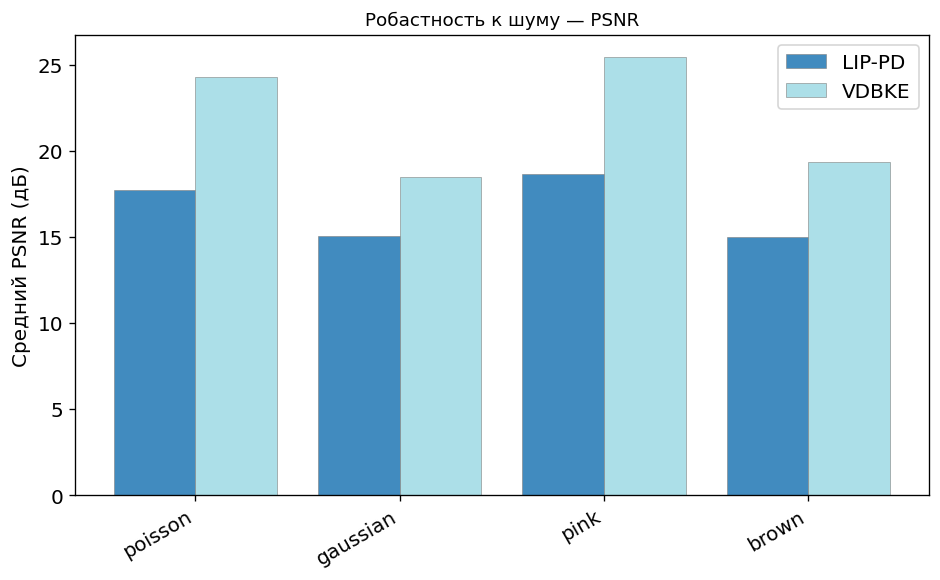

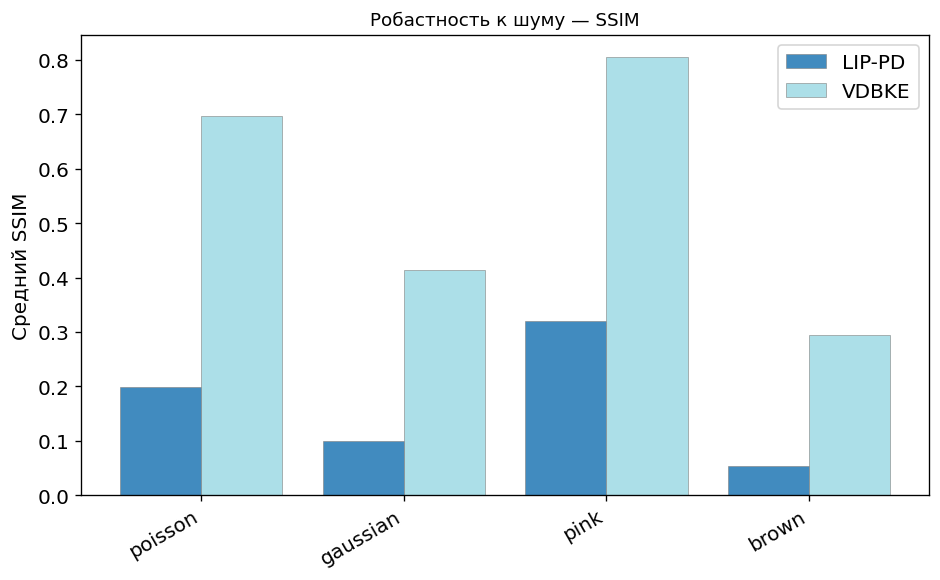

  TeX сохранён: D:\for_proga\franework_deconvolution\framework (9)\presentation_graphics\comparison_tex\noise_dependency_psnr.tex
  TeX сохранён: D:\for_proga\franework_deconvolution\framework (9)\presentation_graphics\comparison_tex\noise_dependency_ssim.tex

══════════════════════════════════════════════════════════
  Сравнительный анализ завершён!
  Графики: D:\for_proga\franework_deconvolution\framework (9)\presentation_graphics\comparison_figures
  TeX:     D:\for_proga\franework_deconvolution\framework (9)\presentation_graphics\comparison_tex
══════════════════════════════════════════════════════════


In [5]:
# ══════════════════════════════════════════════════════════════════════════════
# 10. Таблица средних PSNR и SSIM по наборам данных для разных методов
# ══════════════════════════════════════════════════════════════════════════════
df_pivot = vis.build_table_mean_psnr_ssim(
    all_data, datasets, tex_dir=TEX_DIR,
)
display(df_pivot)

# ══════════════════════════════════════════════════════════════════════════════
# 11. Итоговая таблица количественных метрик
# ══════════════════════════════════════════════════════════════════════════════
df_full = vis.build_table_full_quantitative(
    all_data, datasets, results_root=RESULTS_ROOT, tex_dir=TEX_DIR,
)
display(df_full)

# ══════════════════════════════════════════════════════════════════════════════
# 7. Зависимость от шума (PSNR + SSIM)
# ══════════════════════════════════════════════════════════════════════════════
vis.plot_noise_dependency(
    df_global, fig_dir=FIG_DIR, tex_dir=TEX_DIR,
    fig_prefix="comparison_figures",
)

print("\n══════════════════════════════════════════════════════════")
print("  Сравнительный анализ завершён!")
print(f"  Графики: {FIG_DIR}")
print(f"  TeX:     {TEX_DIR}")
print("══════════════════════════════════════════════════════════")